# 1. Imagem escolhida

A imagem foi tira de um artigo chamado "Global Coverage of Cetacean Line-Transect Surveys: Status Quo, Data Gaps and Future Challenges" escrito por Kaschner et al. O artigo busca elaborar um dataset geoespacial com base em levantamentos visuais do tipo transecto linear de populações de cetáceos entre 1975 e 2005. Com base nesse dataset ele buscaram analisar a distribuição espacial, abundância de levantamentos por espécies e por região e lacuna entre levantamentos ao longo dos anos. 

O gráfico abaixo busca mostrar a cobertura dos censos por latitude e por espécie, em preto está a cobertura realizada pelos censos, em cinza o habitat natural deste animal e traçado mostra momentos onde o censo seperou a latitude esperada.

<img src="barras_original.png" alt="Foto de perfil" width="800">

# 2. Diagnóstico

Comparando os erros encontrados a lista de sete erros recorrentes temos:


| Erro Recorrente | Está presente no gráfico? |
| -------- | -------- |
| Truncamento  | Não |
| Quebra de barra  | Não |
| Falta de ordem  | Não |
| Uso de grade e rótulo | Sim, o uso excessivo de rótulo e falta de separação entre as barras dificultam a leitura do gráfico |
| Empilhar e comparar ao meio | Não |
| Layout circular | Não |
| Confundir % com p.p | Não |

No entanto este gráfico também possui erros que não se encaixam nessa lista como: 

1. Rótulos virados a 90 graus, dificultando a leitura
2. Falta de uma legenda na imagem
3. Falta de título 


# 3. Reconstrução

Os dados usados para fazer essa reconstrução deste gráfico foram estimados usando a inteligência artificial pois eles não foram disponibilizados no artigo original.

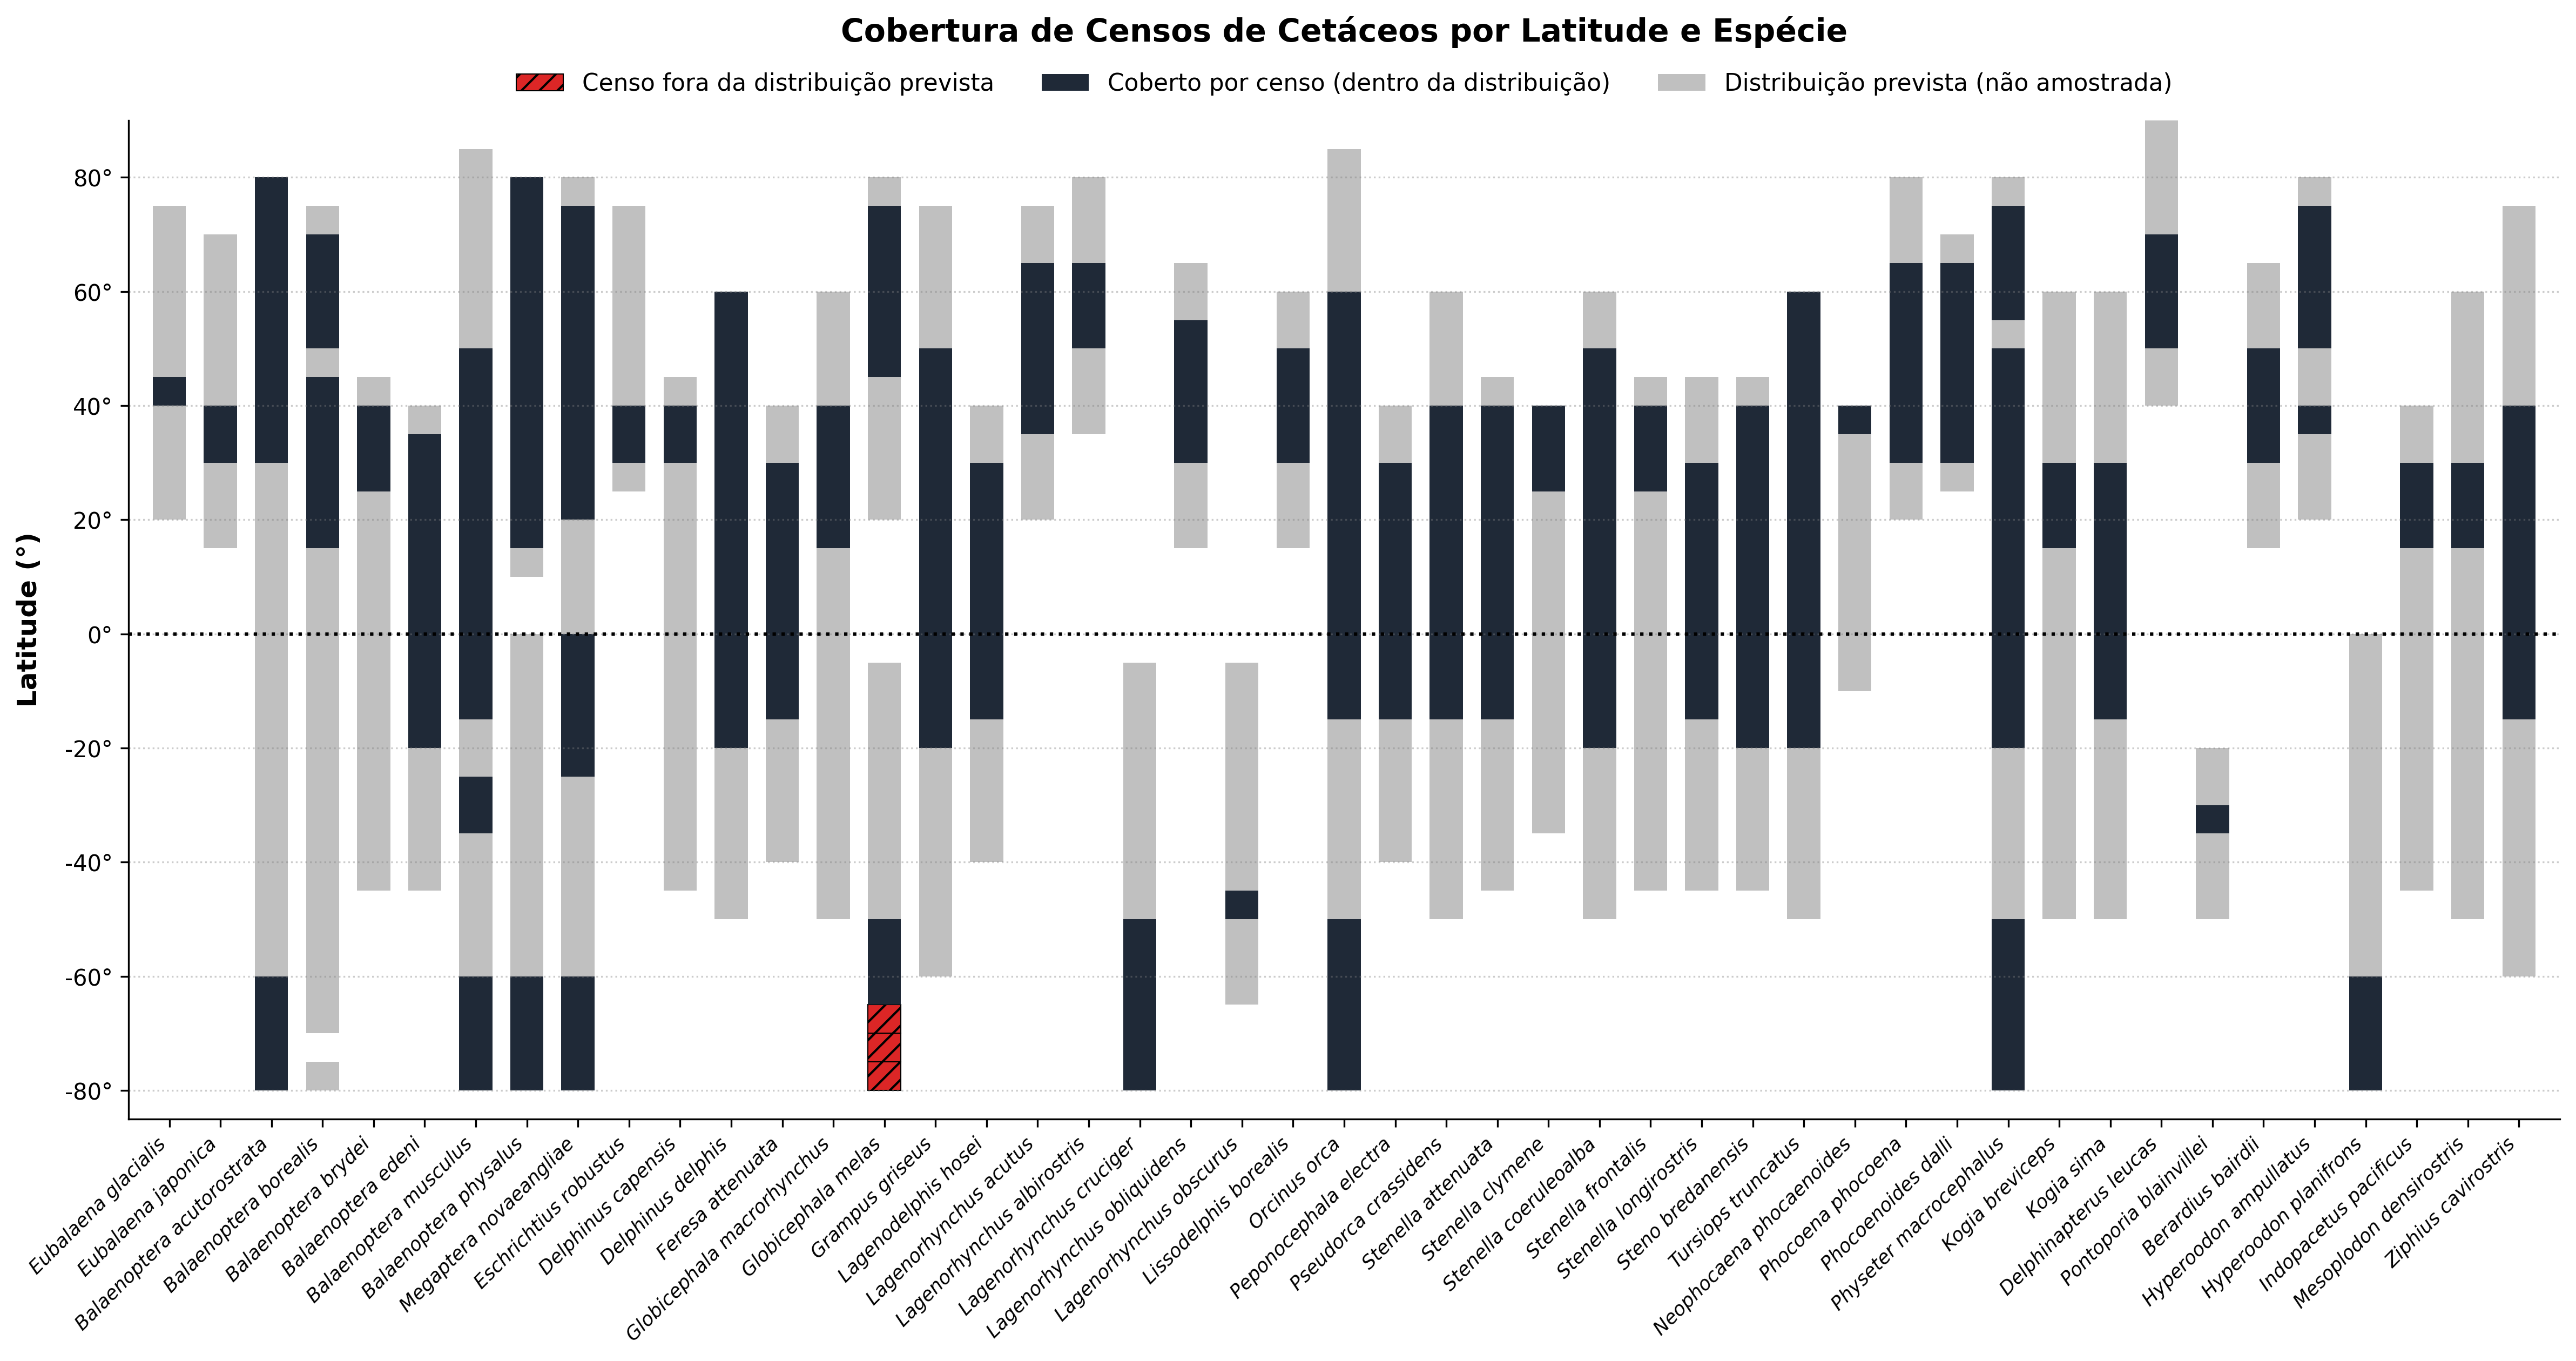

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv('dados_estimados.csv')

styles = {
    'coberto_por_censo': ('#1F2937', 'Coberto por censo (dentro da distribuição)', None),
    'distribuicao_prevista': ('#C0C0C0', 'Distribuição prevista (não amostrada)', None),
    'censo_fora_da_distribuicao': ('#DC2626', 'Censo fora da distribuição prevista', '///')
}

especies_list = df['especie'].unique()
especies_map = {sp: i for i, sp in enumerate(especies_list)}

fig, ax = plt.subplots(figsize=(16, 8.5), dpi=300)

for cat, group in df.groupby('categoria'):
    if cat not in styles:
        continue
    color, label, hatch = styles[cat]
    x_coords = group['especie'].map(especies_map)
    heights = group['latitude_max'] - group['latitude_min']
    
    ax.bar(x_coords,
        heights,
        bottom=group['latitude_min'],
        width=0.65,
        color=color,
        hatch=hatch,
        edgecolor='black' if hatch else 'none',
        linewidth=0.5,
        label=label
    )

ax.axhline(0, color='black', ls=':', lw=1.5, zorder=5)
ax.set_ylabel('Latitude (°)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_yticks(range(-80, 91, 20), [f'{y}°' for y in range(-80, 91, 20)], fontsize=10)
ax.set_ylim(-85, 90)

ax.set_xticks(range(len(especies_list)))
ax.set_xticklabels(especies_list, rotation=45, ha='right', fontsize=8.5, fontstyle='italic')
ax.set_xlim(-0.8, len(especies_list) - 0.2)
ax.grid(True, axis='y', ls=':', color='gray', alpha=0.4)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.07), ncol=3, frameon=False, fontsize=10.5)

ax.set_title('Cobertura de Censos de Cetáceos por Latitude e Espécie', fontsize=14, fontweight='bold', pad=35)

plt.tight_layout()
plt.show()

# 4. Justificativa

A reconstrução conseguiu sanar os maiores problemas do gráfico original, mas sem deixar de responder sua pergunta: Qual a cobertura dos censos de cada espécie por latitude? Ele mantem a mesma ordenação original, mas separando as barras para facilitar a visualização. A linha do equador foi mantida pois uma das coisas que o artigo queria demonstrar era a falta de censos no sul global, portanto é relevante fazer essa distinção visual. Os rótulos foram colocados na parte inferior do gráfico e com uma leve inclinação para facilitar a leitura, além de ter incluído uma legenda e um título,assim toda informação necessária para entender o gráfico estão contidas na imagem, facilitando a interpretação do leitor.